# Sinca exploratory data analysis

## Main imports

- sqlite: Never called directly in this notebook; analysis/data.py's connect() wraps sqlite3.connect() and every SQL query below goes through that.
- urllib.request: stdlib HTTP client, used only in section 1 to replicate the raw scrape by hand
- pathlib.Path: object-oriented filesystem paths; Path.cwd() gets the current working directory, and / below joins path segments (ROOT / "analysis" / "results.json") instead of os.path.join.
- matplotlib.pyplot as plt: Every chart in this notebook. plt.rcParams is matplotlib's global style dictionary: .update({...}) overrides chosen defaults for every figure created afterward, so each chart doesn't need to repeat spines.top=False etc.
- numpy as np: Array math.
- pandas as pd: DataFrames/Series used throughout for tables.
- scipy.stats: linregress and pearsonr.
- analysis.data / analysis.compute: This project's own modules; the actual pipeline code being demonstrated, not a third-party library.
- pd.set_option("display.max_columns", 10): Pandas display setting.

In [2]:
import sqlite3
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from analysis import data, compute


ROOT = Path.cwd()

BLUE, ORANGE, GREEN, RED, MUTED = "#2a78d6", "#eb6834", "#0ca30c", "#d03b3b", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "text.color": "#0b0b0b", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "figure.dpi": 110,
})
pd.set_option("display.max_columns", 10)

## Finding a way into Sinca

SINCA has no documented public API. The path in: read the region page for station IDs, read a station page for every dataset's macropath/macro, then trace the chart widget's own network requests to find the CGI script that actually serves numbers instead of an HTML chart.

In [3]:
stations = data.stations()
print(f"{len(stations)} stations in the database")
stations.head(8)

14 stations in the database


,id,name
0,116,Cerrillos I
1,149,Quilicura I
2,190,Pudahuel (Acreditada)
3,197,Talagante
4,228,Cerro Navia
5,233,Puente Alto
6,239,Las Condes (Acreditada)
7,260,El Bosque (Acreditada)


In [4]:
import re


STATION_ID = "273"
page = urllib.request.urlopen(
    f"https://sinca.mma.gob.cl/index.php/estacion/index/id/{STATION_ID}",
    timeout=30,
).read().decode("utf-8", "replace")

links = re.findall(
    r"macropath=([^&]+)&amp;macro=([^&]+)&amp;from=(\d{6})&amp;to=(\d{6})", page
)
print(f"{len(links)} dataset links found on the station page, e.g.:")
for macropath, macro, frm, to in links[:4]:
    print(f"    {macropath:<22} {macro:<20} {frm}..{to}")


30 dataset links found on the station page, e.g.:
    ./RM/D14/Cal/0001      0001.diario.diario   970719..170108
    ./RM/D14/Cal/0001      0001.horario.horario 970718..170109
    ./RM/D14/Cal/0002      0002.diario.diario   090326..260822
    ./RM/D14/Cal/0002      0002.horario.horario 090325..260823


In [5]:
url = (
    "https://sinca.mma.gob.cl/cgi-bin/APUB-MMA/apub.tsindico2.cgi"
    "?outtype=xcl&macro=./RM/D14/Cal/PM25//PM25.diario.diario.ic"
    "&from=250101&to=250107&path=/usr/airviro/data/CONAMA/&lang=esp"
)
raw = urllib.request.urlopen(url, timeout=30).read().decode("utf-8")
print(raw)

FECHA (YYMMDD);HORA (HHMM);Registros validados;Registros preliminares;Registros no validados;
250101;0000;11;;;
250102;0000;9;;;
250103;0000;13;;;
250104;0000;12;;;
250105;0000;12;;;
250106;0000;11;;;



## Single station extraction

sinca.py wraps the discovery above into three functions: list_stations, station_datasets, and fetch_series. It also resolves two format quirks found by inspecting raw responses: 2-digit years in YYMMDD dates, and comma decimal separators.

In [6]:
import sinca


rows = list(sinca.fetch_series(
    "./RM/D14/Cal/PM25", "PM25.diario.diario", "2024-01-01", "2024-01-10"
))
pd.DataFrame(rows)

,date,time,validated,preliminary,unvalidated
0,2024-01-01,00:00,8.0,None,None
1,2024-01-02,00:00,13.0,None,None
2,2024-01-03,00:00,16.0,None,None
3,2024-01-04,00:00,17.0,None,None
4,2024-01-05,00:00,12.0,None,None
5,2024-01-06,00:00,11.0,None,None
6,2024-01-07,00:00,7.0,None,None
7,2024-01-08,00:00,9.0,None,None
8,2024-01-09,00:00,9.0,None,None


## Scaling to full region

The schema is checked to verify its contents, then a full sweep is run across the region.

In [7]:
with data.connect() as db:
    schema = pd.read_sql_query(
        "SELECT name, type FROM sqlite_master WHERE type='table'", db
    )
print(schema.to_string(index=False))

           name  type
       stations table
         series table
sqlite_sequence table
   measurements table


In [8]:
with data.connect() as db:
    tables = pd.read_sql_query(
            "SELECT name FROM sqlite_master WHERE type='table'"
            , db
        )["name"]

    all_cols = pd.concat(
        [pd.read_sql_query(f"PRAGMA table_info('{t}')", db).assign(table=t)
        for t in tables],
        ignore_index=True
    )

all_cols

,cid,name,type,notnull,dflt_value,pk,table
0,0,id,INTEGER,0,None,1,stations
1,1,name,TEXT,1,None,0,stations
2,2,region,TEXT,1,None,0,stations
3,0,id,INTEGER,0,None,1,series
4,1,station_id,INTEGER,1,None,0,series
5,2,code,TEXT,1,None,0,series
6,3,name,TEXT,0,None,0,series
7,4,kind,TEXT,1,None,0,series
8,5,freq,TEXT,1,None,0,series
9,6,macropath,TEXT,1,None,0,series


In [9]:
with data.connect() as db:
    counts = pd.read_sql_query(
        """
        SELECT
            (SELECT COUNT(*) FROM stations) AS stations,
            (SELECT COUNT(*) FROM series) AS series,
            (SELECT COUNT(*) FROM measurements) AS measurements
        """,
        db,
    )
counts

,stations,series,measurements
0,14,138,5587252


In [10]:
with data.connect() as db:
    per_station = pd.read_sql_query(
        """
        SELECT st.name AS station, COUNT(*) AS rows,
            MIN(m.ts) AS first, MAX(m.ts) AS last
        FROM measurements m
        JOIN series s ON s.id = m.series_id
        JOIN stations st ON st.id = s.station_id
        GROUP BY st.id ORDER BY rows DESC
        """,
        db
    )
per_station

,station,rows,first,last
0,Parque O'Higgins,644032,1997-04-02 00:00,2026-07-17 11:00
1,La Florida (Acreditada),637509,1997-04-07 00:00,2026-07-17 11:00
2,Pudahuel (Acreditada),631261,1997-04-04 00:00,2026-07-17 11:00
3,El Bosque (Acreditada),606130,1997-04-02 00:00,2026-07-17 11:00
4,Las Condes (Acreditada),601718,1997-04-02 00:00,2026-07-17 11:00
5,Independencia,503990,1997-04-02 00:00,2021-08-02 02:00
6,Cerro Navia,496965,2001-03-24 00:00,2026-07-17 11:00
7,Puente Alto,456664,2008-05-21 00:00,2026-07-17 11:00
8,Talagante,412805,2008-05-26 00:00,2026-07-17 11:00
9,Cerrillos I,375240,1997-04-02 00:00,2017-01-12 10:00


## Loading and checking the scientific stack

In [11]:
import sklearn


for mod in (pd, np, sklearn):
    print(f"{mod.__name__:<12} {mod.__version__}")

pandas       3.0.5
numpy        2.5.2
sklearn      1.9.0


Merging daily PM2.5 with daily-aggregated weather and running .describe() on the result is what surfaced a problem: a couple of rows with wind speeds around 10²² m/s, and roughly 480 rows with temperatures near −40°C in a basin that has never recorded below about −8°C. Instrument faults, not weather.

In [12]:
raw_wind = data.daily_weather("WSPD")
print("Wind speed (m/s), BEFORE cleaning:")
print(raw_wind["wspd"].describe())
print()
print("The two offending rows (1st and 2nd):")
raw_wind.sort_values("wspd", ascending=False).head(5)

Wind speed (m/s), BEFORE cleaning:
count    7.045300e+04
mean     1.445336e+18
std      2.859432e+20
min      0.000000e+00
25%      8.422394e-01
50%      1.163022e+00
75%      1.557885e+00
max      6.788550e+22
Name: wspd, dtype: float64

The two offending rows (1st and 2nd):


,station_id,station,date,wspd
55278,262,La Florida (Acreditada),2024-03-27,6.788550e+22
55277,262,La Florida (Acreditada),2024-03-26,3.394275e+22
69765,273,Parque O'Higgins,2024-08-27,1.250000e+01
69764,273,Parque O'Higgins,2024-08-26,1.250000e+01
37744,239,Las Condes (Acreditada),2016-11-18,7.361411e+00


In [13]:
df = data.station_daily_table("PM25")
print()
print("Wind speed (m/s), AFTER cleaning:")
print(df["wspd"].describe())

data QC: dropped 485 rows with sensor-fault readings

Wind speed (m/s), AFTER cleaning:
count    63409.000000
mean         1.251126
std          0.622787
min          0.000000
25%          0.828230
50%          1.138887
75%          1.523934
max          7.361411
Name: wspd, dtype: float64


In [14]:
df.isnull().sum()

station_id        0
station           0
date              0
value             0
temp          14166
rhum          14497
wspd          13685
dtype: int64

## Trends and seasonality

Region-wide trend: -0.440 µg/m³ per year (p = 0.0000)


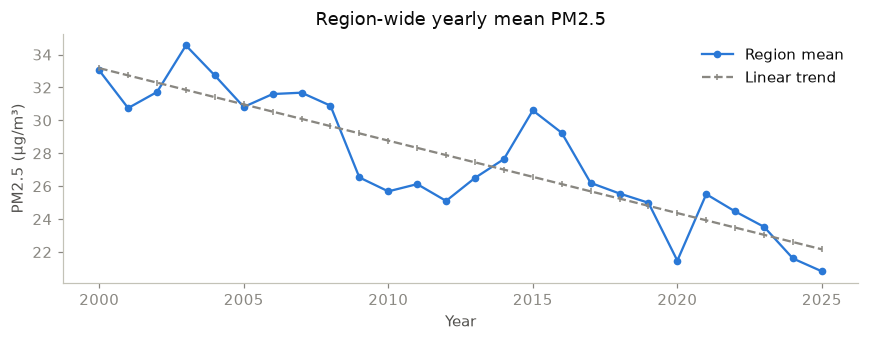

In [15]:
trends = compute.trends_and_seasonality(df)

stations_t =list(trends["by_station"].values())
all_years = sorted({y for s in stations_t for y in s["years"]})

region_mean = [
    np.mean([s["mean"][s["years"].index(yr)] for s in stations_t if yr in s["years"]])
    for yr in all_years
]

slope, intercept, r, p, se = stats.linregress(all_years, region_mean)
print(f"Region-wide trend: {slope:+.3f} µg/m³ per year (p = {p:.4f})")

linear_trend = [intercept + slope * y for y in all_years]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(all_years, region_mean, color=BLUE, marker="o", ms=4, label="Region mean")
ax.plot(all_years, linear_trend, color=MUTED, marker="|", ms=4, ls="--", label="Linear trend")
ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Region-wide yearly mean PM2.5")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [16]:
sig_stations = sorted(stations_t, key=lambda s: s["slope_per_year"])

print(f"{'Station':<28} {'slope (µg/m³/yr)':>18} {'p-value':>10}    significant?")
for s in sig_stations:
    sig = "yes" if s["p_value"] < 0.05 else "no"
    print(f"{s['name']:<28} {s['slope_per_year']:>18.3f} {s['p_value']:>10.4f}    {sig}")

Station                        slope (µg/m³/yr)    p-value    significant?
Quilicura                                -0.840     0.0033    yes
Parque O'Higgins                         -0.663     0.0000    yes
La Florida (Acreditada)                  -0.552     0.0000    yes
El Bosque (Acreditada)                   -0.472     0.0229    yes
Cerro Navia                              -0.374     0.0028    yes
Las Condes (Acreditada)                  -0.369     0.0000    yes
Pudahuel (Acreditada)                    -0.361     0.0001    yes
Puente Alto                              -0.327     0.0498    yes
Cerrillos I                              -0.299     0.6254    no
Independencia                            -0.180     0.4251    no
Quilicura I                               0.015     0.9690    no
Talagante                                 0.121     0.5213    no


Most of the declining stations reject the null hypothesis of no trend (p-value < 0.05) — their downward trends in PM2.5 are statistically significant, not noise.

Checking at the climatology, it seems to be that the months with most pollutant concentration are usually during mid-year, while the less pollutant during the end/beginning.

Moreover, Saturdays had been historically the days with more pollution concentrations than others.

In [ ]:
clim = trends["climatology"]
pd.DataFrame(clim)

,month,mean,std,n
0,1,18.30,9.37,6390
1,2,18.90,9.22,5716
2,3,20.52,8.70,5942
3,4,27.86,12.65,6095
4,5,41.15,19.16,6483
5,6,45.09,23.52,6343
6,7,44.36,20.69,6557
7,8,32.54,15.94,6529
8,9,22.70,10.56,6248
9,10,16.66,6.52,6363


In [37]:
dow = trends["day_of_week"]
pd.DataFrame(dow)

,day,mean
0,0,24.91
1,1,26.36
2,2,26.69
3,3,27.14
4,4,28.04
5,5,28.82
6,6,26.38


Checking it with subplots is way more notorious.

This behaviour has to do with Santiango de Chile location and surrondings. The city is adjacent to Cordillera de los Andes from the East and Cordillera de la costa from the West. During cold seasons (Mid year in the South hemisphere) cold air gets trapped under a layer of warm air near the ground. This block is called a thermal inversion and stops dirty air from rising, plus the two giant natural barricades blocking it disipating from the sides create a dome of pollution right above the city that locals are familiarized.

Regarding the days of the week, the increment during weekends might be related with nightlife during fridays.

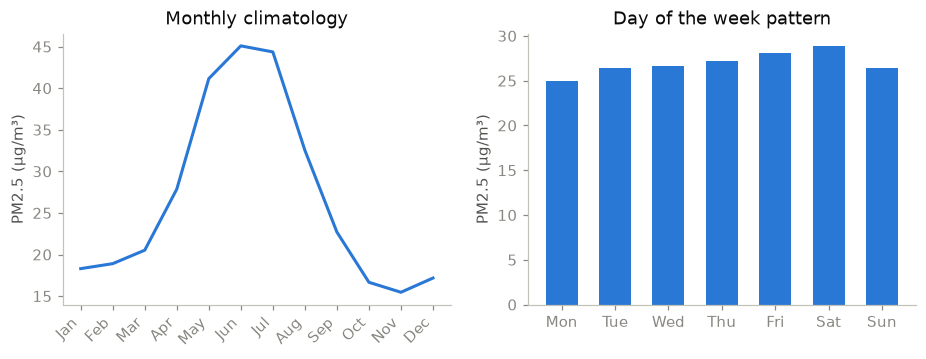

In [ ]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

axes[0].plot(clim["month"], clim["mean"], color=BLUE, lw=2)
axes[0].set_xticks(clim["month"])
axes[0].set_xticklabels(month_names, rotation=45, ha="right")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_title("Monthly climatology")

axes[1].bar(dow["day"], dow["mean"], color=BLUE, width=0.6)
axes[1].set_xticks(dow["day"])
axes[1].set_xticklabels(dow_names, rotation=0)
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_title("Day of the week pattern")

plt.show()

Let's see it with numbers again

In [36]:
winter = np.mean([clim["mean"][clim["month"].index(m)] for m in (5, 6, 7, 8)])
summer = np.mean([clim["mean"][clim["month"].index(m)] for m in (11, 12, 1, 2)])

print(f"Winter (May-Aug) mean: {winter:.2f} µg/m³")
print(f"Summer (Nov-Feb) mean: {summer:.2f} µg/m³")
print(f"Ratio: {winter/summer:.1f}x")

Winter (May-Aug) mean: 40.79 µg/m³
Summer (Nov-Feb) mean: 17.46 µg/m³
Ratio: 2.3x


In [54]:
mon = dow["mean"][0]
sat = dow["mean"][5]

print(f"{'Monday mean':<15} {mon:.2f} µg/m³")
print(f"{'Saturday mean':<15} {sat:.2f} µg/m³")
print(f"Ratio {sat/mon:.1f}x")

Monday mean     24.91 µg/m³
Saturday mean   28.82 µg/m³
Ratio 1.2x


So far it seems to be healthier to be in Santiago de Chile during summer, showing lower pollutant concentrations. However, the day-of-week results are mixed with all season, not giving certanty about it. Let's dive with pollution and weather in more detail.

compute.weather_correlation(df): Runs a scipy.stats.pearsonr()

In [68]:
weather = compute.weather_correlation(df)

In [69]:
weather_tuple = (
    ("temp", "Temperature"),
    ("rhum", "Humidity"),
    ("wspd", "Wind speed")
)

for var, label in weather_tuple:
    c = weather["correlations"][var]
    print(f"{label:<12} r = {c['r']:+.3f}    (n = {c['n']:,}, p < 0.001)")

Temperature  r = -0.405    (n = 59,715, p < 0.001)
Humidity     r = +0.197    (n = 59,715, p < 0.001)
Wind speed   r = -0.326    (n = 59,715, p < 0.001)
